In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("C:/Users/user1/Downloads/house_price_prediction_dataset (1).csv")

# Inspection
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nFirst Rows:\n", df.head())
print("\nSummary Statistics:\n", df.describe(include='all'))

Shape: (125, 9)

Data Types:
 House_ID                     int64
Area_m2                    float64
Bedrooms                   float64
Bathrooms                  float64
House_Age_Years            float64
Distance_to_City_km        float64
Parking_Spaces             float64
Neighborhood                   str
House_Price_Million_RWF    float64
dtype: object

First Rows:
    House_ID  Area_m2  Bedrooms  Bathrooms  House_Age_Years  \
0      1001    144.6       2.0        2.0             15.0   
1      1002    101.9       4.0        4.0             15.5   
2      1003    157.1       3.0        2.0              8.9   
3      1004    254.2       3.0        2.0             15.5   
4      1005     96.7       3.0        2.0              9.5   

   Distance_to_City_km  Parking_Spaces Neighborhood  House_Price_Million_RWF  
0                27.40             0.0  Kigali City                    104.8  
1                 5.97             1.0         Huye                    137.0  
2                

In [2]:
# Check missing values
print("Missing Values:\n", df.isnull().sum())

# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

# Action: Remove exact duplicates if any
df = df.drop_duplicates()

# Action: Impute missing numerical values with median
num_cols = ['Area_m2', 'Bedrooms', 'Bathrooms', 'House_Age_Years', 'Distance_to_City_km', 'Parking_Spaces']
for col in num_cols:
    if col in df.columns and df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Action: Impute missing categorical values with mode
if 'Neighborhood' in df.columns and df['Neighborhood'].isnull().sum() > 0:
    df['Neighborhood'] = df['Neighborhood'].fillna(df['Neighborhood'].mode()[0])

Missing Values:
 House_ID                   0
Area_m2                    2
Bedrooms                   1
Bathrooms                  1
House_Age_Years            1
Distance_to_City_km        1
Parking_Spaces             1
Neighborhood               1
House_Price_Million_RWF    1
dtype: int64
Duplicate rows: 5


In [3]:
# Function to cap outliers using IQR
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = np.clip(df[column], lower_bound, upper_bound)
    return df

# Apply capping to numerical features
num_cols = ['Area_m2', 'House_Age_Years', 'Distance_to_City_km', 'House_Price_Million_RWF']
for col in num_cols:
    if col in df.columns:
        df = cap_outliers(df, col)

# Display output to confirm completion
print("Outlier capping complete!")
print("\nUpdated summary statistics:")
print(df[num_cols].describe())

Outlier capping complete!

Updated summary statistics:
          Area_m2  House_Age_Years  Distance_to_City_km  \
count  120.000000       120.000000           120.000000   
mean   117.307083         9.016563             4.713719   
std     53.224848         7.556517             4.120117   
min     26.000000         0.400000             0.070000   
25%     82.025000         3.050000             1.575000   
50%    107.900000         6.800000             3.450000   
75%    139.200000        12.225000             6.922500   
max    224.962500        25.987500            14.943750   

       House_Price_Million_RWF  
count               119.000000  
mean                160.710084  
std                  51.327025  
min                  77.700000  
25%                 120.150000  
50%                 152.900000  
75%                 186.950000  
max                 287.150000  


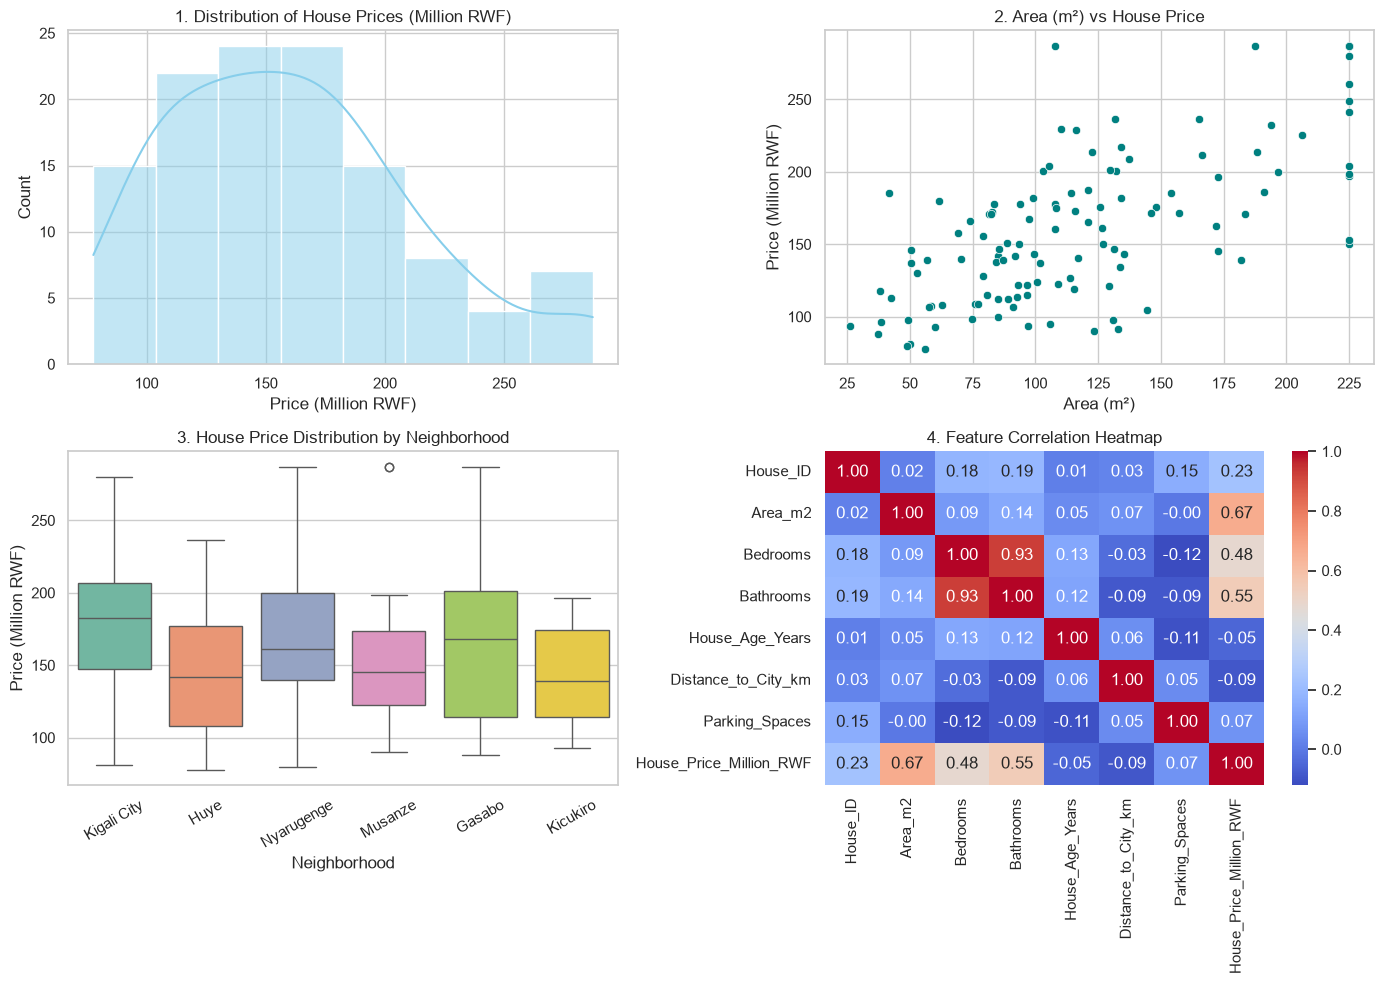

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure plots display directly in the notebook
%matplotlib inline

# Set plot style
sns.set_theme(style="whitegrid")

# Create a 2x2 layout for all four charts
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution of Price (Histogram)
sns.histplot(df['House_Price_Million_RWF'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('1. Distribution of House Prices (Million RWF)')
axes[0, 0].set_xlabel('Price (Million RWF)')

# 2. Scatter Plot: Area vs Price
sns.scatterplot(data=df, x='Area_m2', y='House_Price_Million_RWF', ax=axes[0, 1], color='teal')
axes[0, 1].set_title('2. Area (m²) vs House Price')
axes[0, 1].set_xlabel('Area (m²)')
axes[0, 1].set_ylabel('Price (Million RWF)')

# 3. Boxplot: Price by Neighborhood
sns.boxplot(data=df, x='Neighborhood', y='House_Price_Million_RWF', ax=axes[1, 0], hue='Neighborhood', palette='Set2', legend=False)
axes[1, 0].set_title('3. House Price Distribution by Neighborhood')
axes[1, 0].tick_params(axis='x', rotation=30)
axes[1, 0].set_ylabel('Price (Million RWF)')

# 4. Correlation Heatmap
num_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title('4. Feature Correlation Heatmap')

# Adjust layout spacing and show plots
plt.tight_layout()
plt.show()

| Problem Found | Where | Action Taken | Reason |
| :--- | :--- | :--- | :--- |
| Missing numerical values | `Area_m2`, `House_Age_Years`, etc. | Imputed using Median | Median is robust against skewed data and outliers. |
| Duplicate rows | Entire dataset | Removed duplicates | Prevents over-weighting repeated observations. |
| Extreme/Impossible outliers | `Area_m2`, `House_Price_Million_RWF` | Capped using 1.5 × IQR rule | Retains sample size without letting extreme values distort linear regression. |
| Non-predictive ID column | `House_ID` | Dropped column | `House_ID` is a non-functional identifier with no predictive signal. |

## Part B: Building the Multiple Linear Regression Model

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# 1. Define Features and Target
X = df.drop(columns=['House_ID', 'House_Price_Million_RWF'])
y = df['House_Price_Million_RWF']

# Categorical and Numerical features
categorical_cols = ['Neighborhood']
numerical_cols = [c for c in X.columns if c not in categorical_cols]

# Preprocessor: One-Hot Encoding (drop first category to prevent dummy variable trap)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ]
)

# Build Pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# 3. Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Fit Model
model_pipeline.fit(X_train, y_train)

# 5. Extract & Display Coefficients
feature_names = numerical_cols + list(
    model_pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_cols)
)
coefficients = model_pipeline.named_steps['regressor'].coef_
intercept = model_pipeline.named_steps['regressor'].intercept_

coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
print(f"Intercept: {intercept:.4f}")
print(coef_df)

Intercept: 25.8500
                     Feature  Coefficient
0                    Area_m2     0.578326
1                   Bedrooms     4.073105
2                  Bathrooms    19.152467
3            House_Age_Years    -0.929413
4        Distance_to_City_km    -1.166214
5             Parking_Spaces     9.585079
6          Neighborhood_Huye   -16.923263
7      Neighborhood_Kicukiro   -13.979141
8   Neighborhood_Kigali City    10.860505
9       Neighborhood_Musanze    -4.622506
10   Neighborhood_Nyarugenge     5.890718


# Part C: Evaluation and Interpretation

In [9]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def get_metrics(model, X, y):
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    n = len(y)
    p = X.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    mae = mean_absolute_error(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    return r2, adj_r2, mae, rmse

train_metrics = get_metrics(model_pipeline, X_train, y_train)
test_metrics = get_metrics(model_pipeline, X_test, y_test)

metrics_df = pd.DataFrame({
    'Metric': ['R2 Score', 'Adjusted R2', 'MAE', 'RMSE'],
    'Train': train_metrics,
    'Test': test_metrics
})
print(metrics_df)

        Metric      Train       Test
0     R2 Score   0.763305   0.674365
1  Adjusted R2   0.744260   0.531900
2          MAE  17.321673  22.895455
3         RMSE  23.457576  32.577829


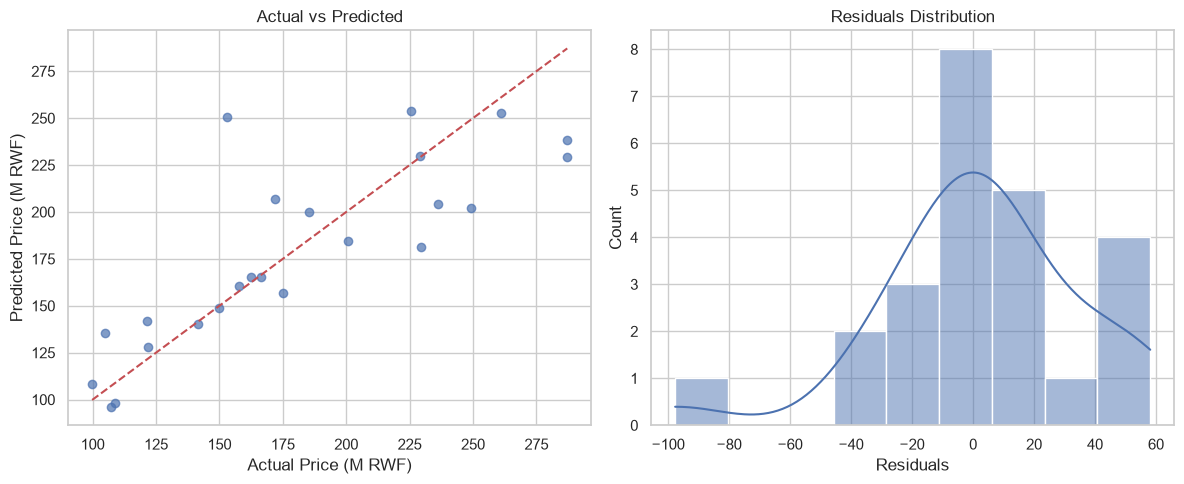

In [10]:
y_test_pred = model_pipeline.predict(X_test)
residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_test_pred, alpha=0.7)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Actual Price (M RWF)')
axes[0].set_ylabel('Predicted Price (M RWF)')
axes[0].set_title('Actual vs Predicted')

# Residual Distribution
sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_xlabel('Residuals')
axes[1].set_title('Residuals Distribution')

plt.tight_layout()
plt.savefig("diagnostics.png")
plt.show()

# Part D: Saving the Model as a .sav File

In [11]:
import joblib

# 1. Save Pipeline
joblib.dump(model_pipeline, 'house_price_model.sav')

# 2. Load Pipeline and Test
loaded_model = joblib.load('house_price_model.sav')

# 3. Test Prediction
sample_house = pd.DataFrame([{
    'Area_m2': 150,
    'Bedrooms': 3,
    'Bathrooms': 2,
    'House_Age_Years': 5,
    'Distance_to_City_km': 7.5,
    'Parking_Spaces': 2,
    'Neighborhood': 'Kicukiro'
}])

prediction = loaded_model.predict(sample_house)[0]
print(f"Predicted Price: {prediction:.2f} Million RWF")

Predicted Price: 154.92 Million RWF


# Part E: Building the Streamlit App

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

# Set page layout and title
st.set_page_config(page_title="Rwanda House Price Predictor", layout="centered")

st.title("🏡 House Price Prediction App (Rwanda)")
st.write("Estimate house market prices in million RWF based on structural and location features.")

# Load saved model pipeline using Streamlit caching
@st.cache_resource
def load_model():
    return joblib.load('house_price_model.sav')

try:
    model = load_model()
except Exception as e:
    st.error("Model file 'house_price_model.sav' not found. Please train and save the model first.")

# Input fields in sidebar
st.sidebar.header("House Features")

area = st.sidebar.number_input("Area (m²)", min_value=20, max_value=1000, value=120)
bedrooms = st.sidebar.slider("Bedrooms", min_value=1, max_value=10, value=3)
bathrooms = st.sidebar.slider("Bathrooms", min_value=1, max_value=8, value=2)
age = st.sidebar.number_input("House Age (Years)", min_value=0, max_value=100, value=5)
distance = st.sidebar.number_input("Distance to City Centre (km)", min_value=0.0, max_value=50.0, value=5.0)
parking = st.sidebar.slider("Parking Spaces", min_value=0, max_value=5, value=1)
neighborhood = st.sidebar.selectbox("Neighborhood", ['Gasabo', 'Huye', 'Kicukiro', 'Kigali City', 'Musanze', 'Nyarugenge'])

# Construct input dataframe matching exact column names
input_data = pd.DataFrame([{
    'Area_m2': area,
    'Bedrooms': bedrooms,
    'Bathrooms': bathrooms,
    'House_Age_Years': age,
    'Distance_to_City_km': distance,
    'Parking_Spaces': parking,
    'Neighborhood': neighborhood
}])

# Make prediction
if st.button("Predict Price"):
    prediction = model.predict(input_data)[0]
    st.success(f"### Estimated Price: {prediction:,.2f} Million RWF")

In [ ]:
!streamlit run app.py